### [ 이미지/ 영상 연산- 비트 연산 ] <hr>

- 픽셀의 비트 단위 연산 수행
- 특정 부분만 추출하거나 사용하기 위한 용도
- 종류
    * bitwise_and() :두 이미지의 비트가 모두 1일 때만 1, 나머지 0=> 특정 부분 추출 시 사용
    * bitwise_or(): 두 이미지의 비트가 모두 0일때만 0, 나머지 1
    * bitwise_xor(): 두 이미지의 비트가 다를 때 1
    * bitwise_not(): 반대


In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils



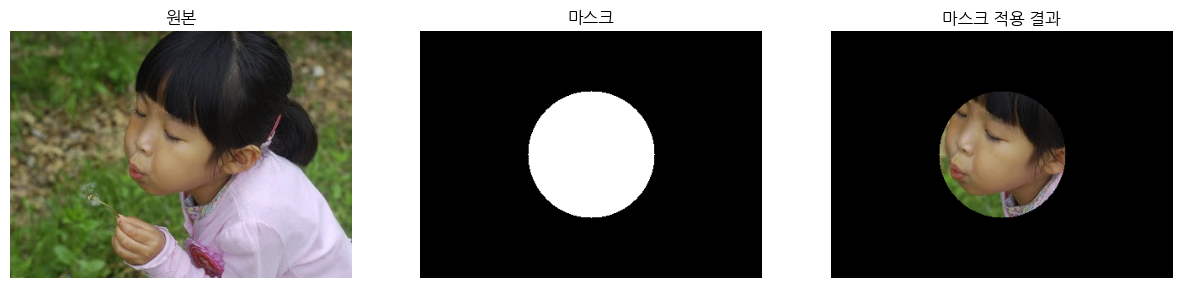

In [13]:

img1= '../Images/girl.jpg'
imgNP= cv2.imread(img1)
# 원본 이미지와 같은 크기의 검정 마스크 생성
maskNP = np.zeros_like(imgNP)

# 이미지 크기
H, W = maskNP.shape[:2]

# 중심 좌표는 (x, y) = (W/2, H/2)
center = (int(W / 2), int(H / 2))

# 흰색 원 그리기
cv2.circle(maskNP, center, 75, (255, 255, 255), -1)

# 마스크 적용
result = cv2.bitwise_and(imgNP, maskNP)

# 출력
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(imgNP, cv2.COLOR_BGR2RGB))
plt.title("원본")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(maskNP, cv2.COLOR_BGR2RGB))
plt.title("마스크")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("마스크 적용 결과")
plt.axis("off")
plt.show()

### [ 이미지 연산- 뺄셈: 다른 부분 추출 ] <hr>

In [15]:
img1= cv2.imread('../Images/robot_arm1.jpg')
img2= cv2.imread('../Images/robot_arm2.jpg')
img1_gray= cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
img2_gray= cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)



diff= cv2.absdiff(img1_gray, img2_gray)

_, diff= cv2. threshold(diff, 1, 255, cv2.THRESH_BINARY)
diff_red= cv2.cvtColor(diff, cv2.COLOR_GRAY2BGR)
diff_red[:,:,2]=0

spot= cv2.bitwise_xor(img2, diff_red)

cv2.imshow('img1', img1)
cv2.imshow('img2', img2)
cv2.imshow('diff', diff)
cv2.imshow('spot', spot)
cv2.waitKey(5000)
cv2.destroyAllWindows()

In [ ]:
cv2.bitwise_and(imgNP, maskNP)

cv_utils_printPlots(1, 3, ["원본", "마스크", "연산결과"], )

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(293, 406, 3), dtype=uint8)

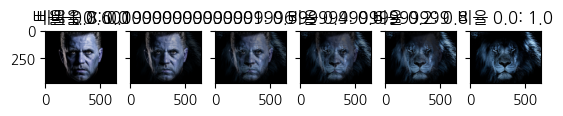

In [9]:
# ---------------------------------------------
# 이미지 합성: 단계별 과정 출력
# ---------------------------------------------

weight= np.linspace(0,1,6)[::-1]

wNP= []
for w in weight:
    wNP.append(cv2.addWeighted(img1, w, img2, 1-w, 0))

wNP= [cv2.addWeighted(img1, w, img2, 1-w, 0) for w in weight]
title= [f'비율 {w}: {1-w}' for w in weight]

cv_utils.printPlots(1, 6, title, wNP)

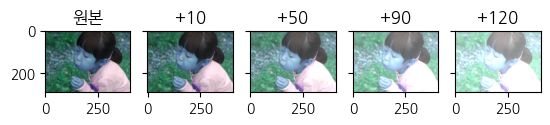

In [ ]:
## ------------------------------------
## 덧셈& 뺄셈 연산
## ------------------------------------
## 덧셈=> 밝게
addNPs= [testNP + value for value in range(10, 131, 40)]
titles= [f'+{value}' for value in range(10, 131, 40)]

for arr in addNPs:
    arr[arr>255]= 255

cv_utils.printPlots(1, 5, ['원본', '+10', '+50', '+90', '+120'], [imgNP]+ addNPs)